# Dual-Agent Evaluation Analysis

Plots derived from `eval_results_dual_agent.csv` (normalized from dual-agent runs).

In [27]:
# Load dual-agent results (handle legacy column alignment if needed)
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "eval_results_dual_agent.csv"
try:
    df_dual_raw = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"CSV not found: {csv_path}")
    df_dual_raw = pd.DataFrame()

if df_dual_raw.empty:
    print("Dual-agent CSV is empty or missing.")
    df_dual = df_dual_raw
else:
    df_dual = df_dual_raw.copy()
    value_all_nan = "Value" in df_dual.columns and df_dual["Value"].isna().all()
    summary_all_nan = "Summary_Metric" in df_dual.columns and df_dual["Summary_Metric"].isna().all()
    metric_family_numeric = "Metric_Family" in df_dual.columns and (
        pd.to_numeric(df_dual["Metric_Family"], errors="coerce").notna().mean() > 0.5
)

    # Legacy alignment: numeric values in Metric_Family, metrics in Condition, families in Runs
    if value_all_nan and summary_all_nan and metric_family_numeric:
        df_dual["Value"] = pd.to_numeric(df_dual["Metric_Family"], errors="coerce")
        df_dual["Summary_Metric"] = df_dual["Condition"]
        df_dual["Metric_Family"] = df_dual["Runs"]
        df_dual["Runs"] = df_dual["Baseline_Prompt_Ver"]
        df_dual["Baseline_Prompt_Ver"] = ""
        df_dual["Condition"] = "Dual_Agent_Store"

    # Normalize numeric values and drop rows without a metric value
    if "Value" in df_dual.columns:
        df_dual["Value"] = pd.to_numeric(df_dual["Value"], errors="coerce")
        df_dual = df_dual[df_dual["Value"].notna()].copy()

    rename_map = {
        "hoangquan456/qwen3-nothink:4b": "qwen3:4b (no-thinking)",
    }
    for col in ["Reasoner_Model", "Matcher_Model"]:
        if col in df_dual.columns:
            df_dual[col] = df_dual[col].replace(rename_map)

    if "Reasoner_Model" in df_dual.columns and "Matcher_Model" in df_dual.columns:
        df_dual["Pair"] = df_dual["Reasoner_Model"].astype(str) + " | " + df_dual["Matcher_Model"].astype(str)

    print(f"Loaded dual-agent rows: {len(df_dual)}")
    print("Columns:", list(df_dual.columns))


Loaded dual-agent rows: 2160
Columns: ['Timestamp', 'Domain', 'Model', 'Reasoner_Model', 'Matcher_Model', 'Temp', 'Eval_Prompt_Ver', 'Baseline_Prompt_Ver', 'Runs', 'Condition', 'Metric_Family', 'Summary_Metric', 'Value', 'Class_Label', 'Pair']


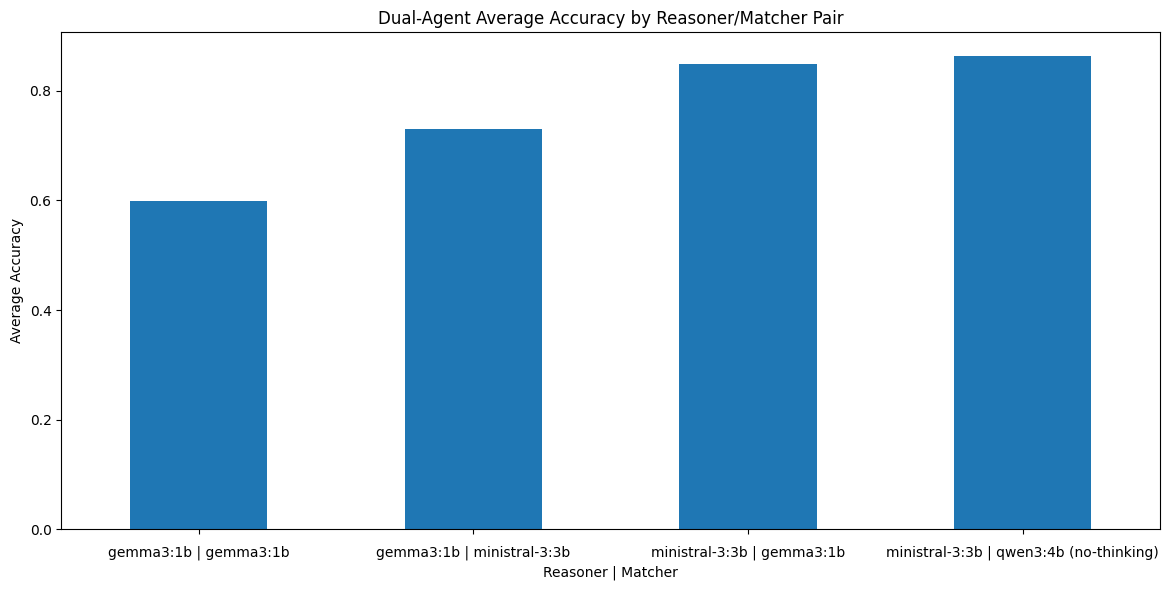

In [28]:
# Average End_to_End accuracy per pair
if df_dual.empty:
    print("No data available for accuracy plot.")
else:
    acc = df_dual[
        (df_dual["Metric_Family"] == "End_to_End")
        & (df_dual["Summary_Metric"] == "Average_Accuracy")
    ].copy()
    if acc.empty:
        print("No End_to_End Average_Accuracy rows found.")
    else:
        if "Pair" not in acc.columns:
            acc["Pair"] = acc["Reasoner_Model"].astype(str) + " | " + acc["Matcher_Model"].astype(str)
        pivot = acc.pivot_table(index="Pair", values="Value", aggfunc="mean")
        ax = pivot.plot(kind="bar", figsize=(12, 6), legend=False)
        ax.set_title("Dual-Agent Average Accuracy by Reasoner/Matcher Pair")
        ax.set_ylabel("Average Accuracy")
        ax.set_xlabel("Reasoner | Matcher")
        ax.tick_params(axis="x", labelrotation=0, pad=8)
        for label in ax.get_xticklabels():
            label.set_ha("center")
        plt.tight_layout()
        plt.show()
        plt.close(ax.figure)


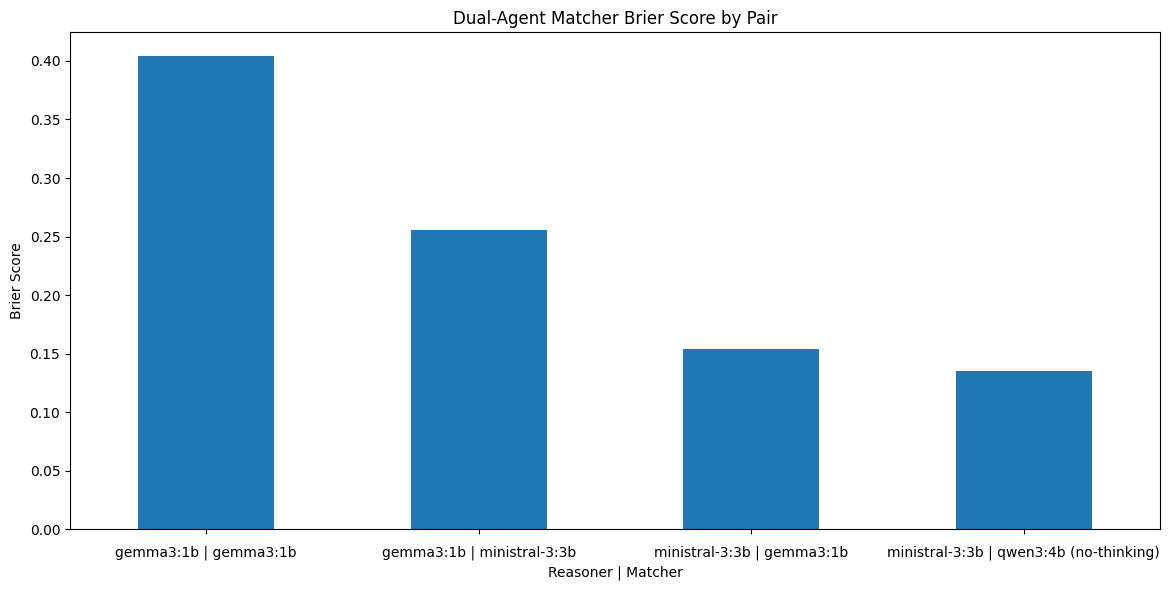

In [29]:
# Matcher calibration: Brier Score per pair
if df_dual.empty:
    print("No data available for Brier plot.")
else:
    brier = df_dual[
        (df_dual["Metric_Family"] == "Matcher")
        & (df_dual["Summary_Metric"].isin(["Brier_Score", "Summary_Metric_Brier_Score"]))
    ].copy()
    if brier.empty:
        print("No Brier Score rows found for Matcher.")
    else:
        if "Pair" not in brier.columns:
            brier["Pair"] = brier["Reasoner_Model"].astype(str) + " | " + brier["Matcher_Model"].astype(str)
        pivot = brier.pivot_table(index="Pair", values="Value", aggfunc="mean")
        ax = pivot.plot(kind="bar", figsize=(12, 6), legend=False)
        ax.set_title("Dual-Agent Matcher Brier Score by Pair")
        ax.set_ylabel("Brier Score")
        ax.set_xlabel("Reasoner | Matcher")
        ax.tick_params(axis="x", labelrotation=0, pad=8)
        for label in ax.get_xticklabels():
            label.set_ha("center")
        plt.tight_layout()
        plt.show()
        plt.close(ax.figure)


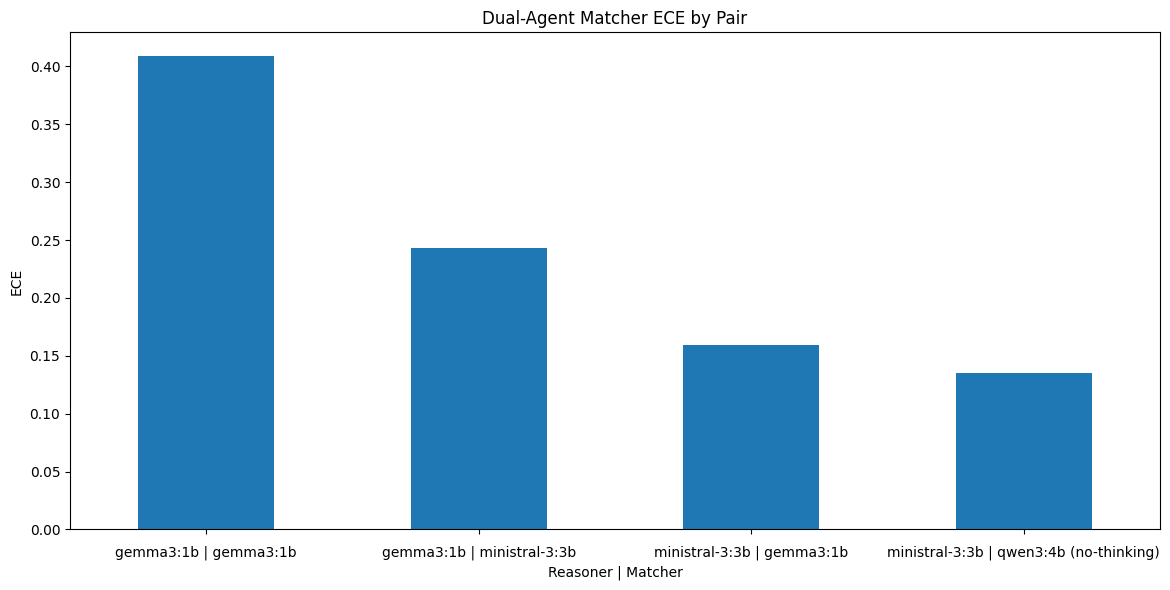

In [30]:
# Matcher calibration: ECE per pair
if df_dual.empty:
    print("No data available for ECE plot.")
else:
    ece = df_dual[
        (df_dual["Metric_Family"] == "Matcher")
        & (df_dual["Summary_Metric"].isin(["ECE", "Summary_Metric_ECE"]))
    ].copy()
    if ece.empty:
        print("No ECE rows found for Matcher.")
    else:
        if "Pair" not in ece.columns:
            ece["Pair"] = ece["Reasoner_Model"].astype(str) + " | " + ece["Matcher_Model"].astype(str)
        pivot = ece.pivot_table(index="Pair", values="Value", aggfunc="mean")
        ax = pivot.plot(kind="bar", figsize=(12, 6), legend=False)
        ax.set_title("Dual-Agent Matcher ECE by Pair")
        ax.set_ylabel("ECE")
        ax.set_xlabel("Reasoner | Matcher")
        ax.tick_params(axis="x", labelrotation=0, pad=8)
        for label in ax.get_xticklabels():
            label.set_ha("center")
        plt.tight_layout()
        plt.show()
        plt.close(ax.figure)


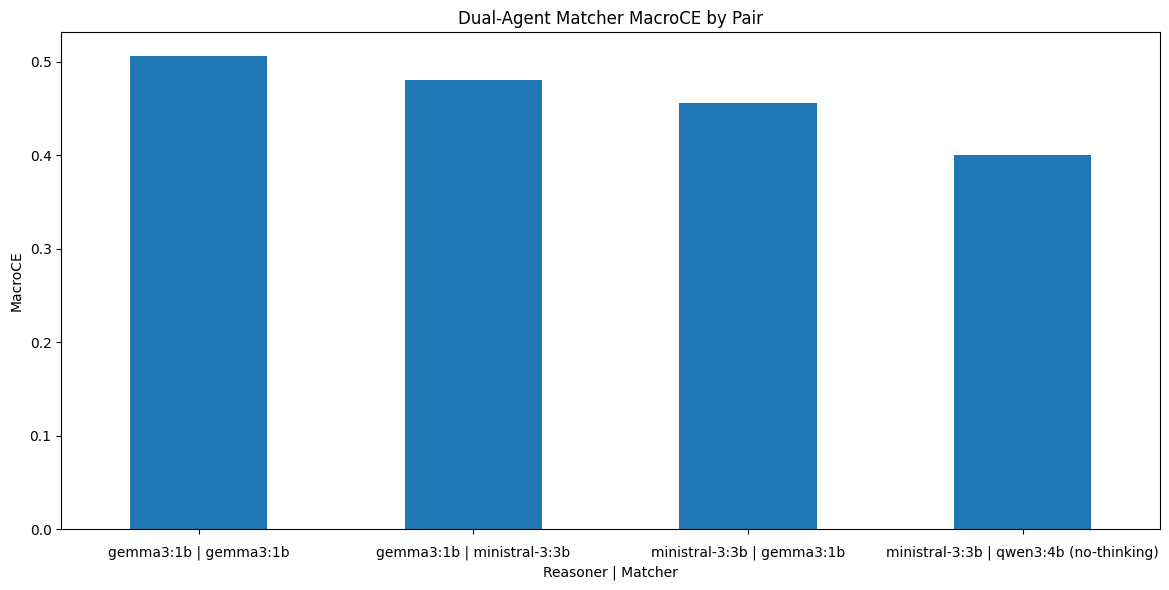

In [31]:
# Matcher calibration: MacroCE per pair
if df_dual.empty:
    print("No data available for MacroCE plot.")
else:
    macro = df_dual[
        (df_dual["Metric_Family"] == "Matcher")
        & (df_dual["Summary_Metric"].isin(["MacroCE", "Summary_Metric_MacroCE"]))
    ].copy()
    if macro.empty:
        print("No MacroCE rows found for Matcher.")
    else:
        if "Pair" not in macro.columns:
            macro["Pair"] = macro["Reasoner_Model"].astype(str) + " | " + macro["Matcher_Model"].astype(str)
        pivot = macro.pivot_table(index="Pair", values="Value", aggfunc="mean")
        ax = pivot.plot(kind="bar", figsize=(12, 6), legend=False)
        ax.set_title("Dual-Agent Matcher MacroCE by Pair")
        ax.set_ylabel("MacroCE")
        ax.set_xlabel("Reasoner | Matcher")
        ax.tick_params(axis="x", labelrotation=0, pad=8)
        for label in ax.get_xticklabels():
            label.set_ha("center")
        plt.tight_layout()
        plt.show()
        plt.close(ax.figure)


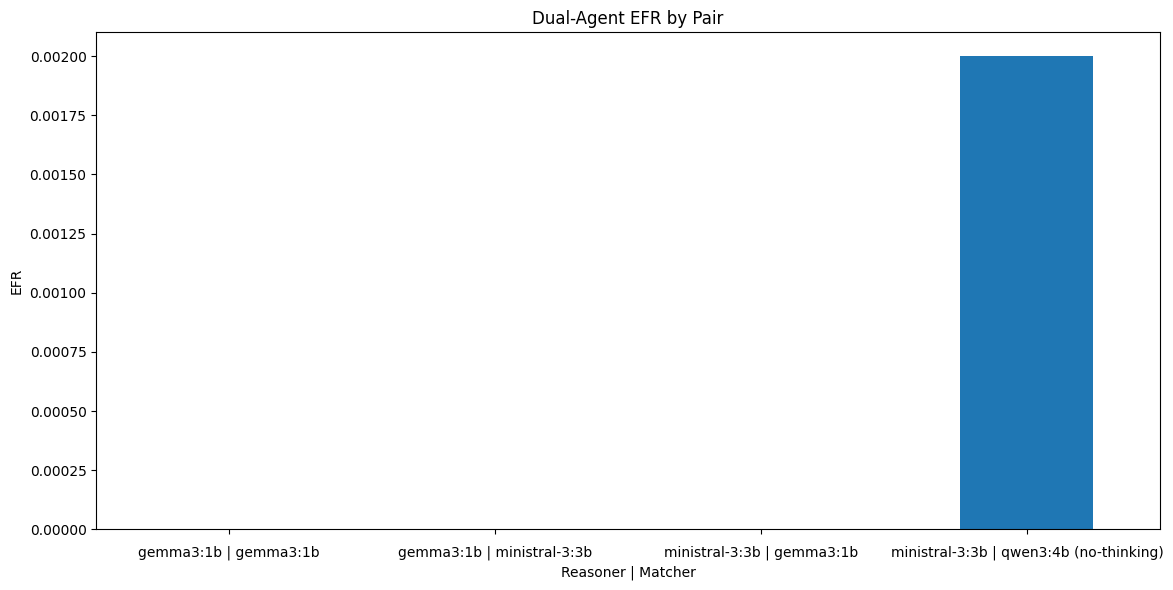

In [32]:
# Stability: Extraction Failure Rate (EFR) per pair
if df_dual.empty:
    print("No data available for EFR plot.")
else:
    efr = df_dual[
        (df_dual["Metric_Family"] == "Stability")
        & (df_dual["Summary_Metric"] == "EFR_Extraction_Failure_Rate")
    ].copy()
    if efr.empty:
        print("No EFR rows found.")
    else:
        if "Pair" not in efr.columns:
            efr["Pair"] = efr["Reasoner_Model"].astype(str) + " | " + efr["Matcher_Model"].astype(str)
        pivot = efr.pivot_table(index="Pair", values="Value", aggfunc="mean")
        ax = pivot.plot(kind="bar", figsize=(12, 6), legend=False)
        ax.set_title("Dual-Agent EFR by Pair")
        ax.set_ylabel("EFR")
        ax.set_xlabel("Reasoner | Matcher")
        ax.tick_params(axis="x", labelrotation=0, pad=8)
        for label in ax.get_xticklabels():
            label.set_ha("center")
        plt.tight_layout()
        plt.show()
        plt.close(ax.figure)


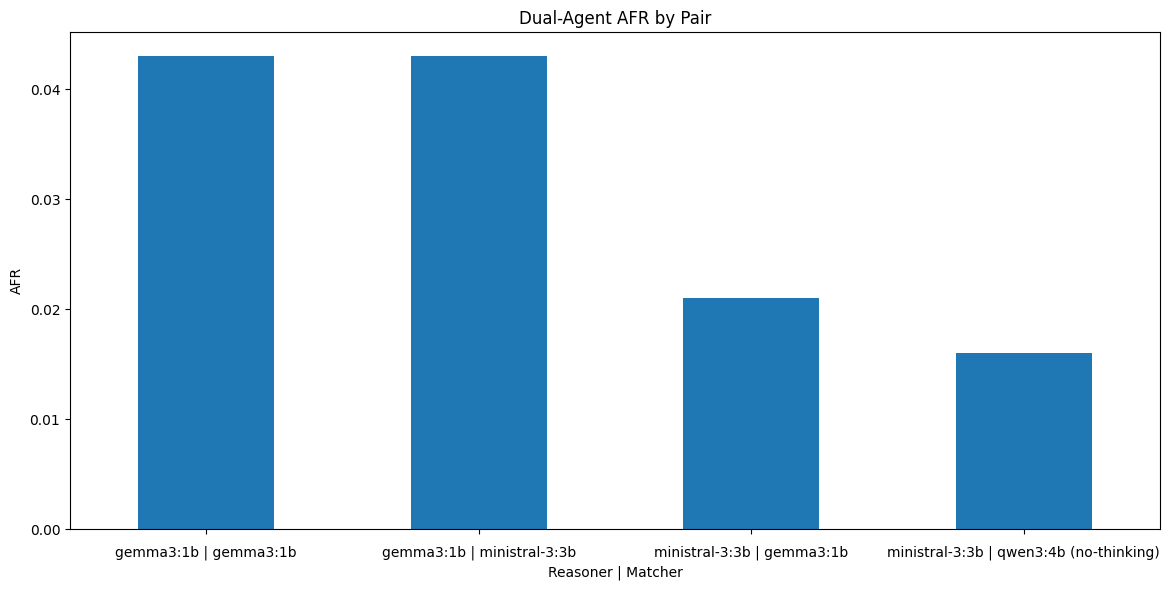

In [33]:
# Stability: Answer Flip Rate (AFR) per pair
if df_dual.empty:
    print("No data available for AFR plot.")
else:
    afr = df_dual[
        (df_dual["Metric_Family"] == "Stability")
        & (df_dual["Summary_Metric"] == "AFR_Answer_Flip_Rate")
    ].copy()
    if afr.empty:
        print("No AFR rows found.")
    else:
        if "Pair" not in afr.columns:
            afr["Pair"] = afr["Reasoner_Model"].astype(str) + " | " + afr["Matcher_Model"].astype(str)
        pivot = afr.pivot_table(index="Pair", values="Value", aggfunc="mean")
        ax = pivot.plot(kind="bar", figsize=(12, 6), legend=False)
        ax.set_title("Dual-Agent AFR by Pair")
        ax.set_ylabel("AFR")
        ax.set_xlabel("Reasoner | Matcher")
        ax.tick_params(axis="x", labelrotation=0, pad=8)
        for label in ax.get_xticklabels():
            label.set_ha("center")
        plt.tight_layout()
        plt.show()
        plt.close(ax.figure)


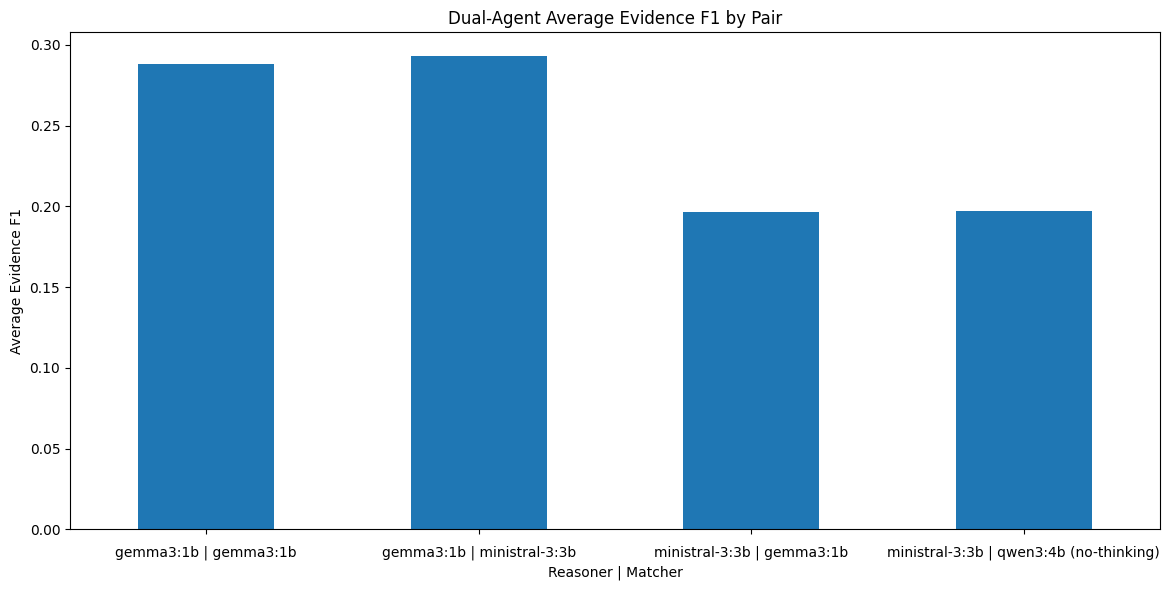

In [34]:
# Reasoning: Average Evidence F1 per pair
if df_dual.empty:
    print("No data available for Evidence F1 plot.")
else:
    f1 = df_dual[
        (df_dual["Metric_Family"] == "Reasoning")
        & (df_dual["Summary_Metric"] == "Average_Evidence_F1")
    ].copy()
    if f1.empty:
        print("No Average_Evidence_F1 rows found.")
    else:
        if "Pair" not in f1.columns:
            f1["Pair"] = f1["Reasoner_Model"].astype(str) + " | " + f1["Matcher_Model"].astype(str)
        pivot = f1.pivot_table(index="Pair", values="Value", aggfunc="mean")
        ax = pivot.plot(kind="bar", figsize=(12, 6), legend=False)
        ax.set_title("Dual-Agent Average Evidence F1 by Pair")
        ax.set_ylabel("Average Evidence F1")
        ax.set_xlabel("Reasoner | Matcher")
        ax.tick_params(axis="x", labelrotation=0, pad=8)
        for label in ax.get_xticklabels():
            label.set_ha("center")
        plt.tight_layout()
        plt.show()
        plt.close(ax.figure)


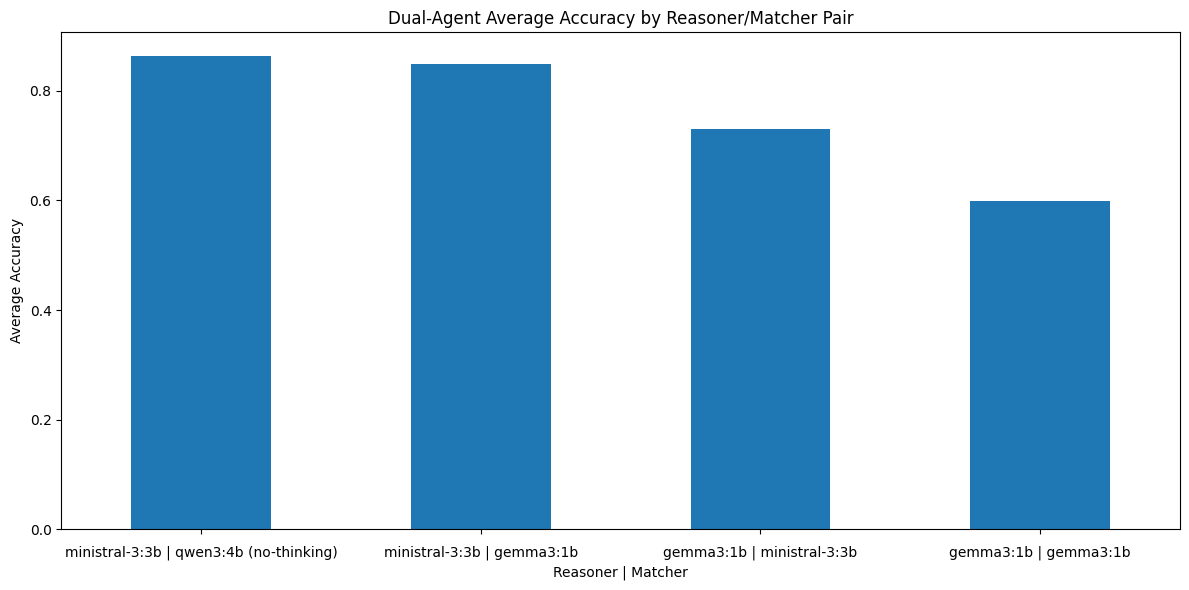

In [35]:
# Accuracy by (Reasoner, Matcher) pair
if df_dual.empty:
    print("No data available for pair accuracy plot.")
else:
    pair_acc = df_dual[
        (df_dual["Metric_Family"] == "End_to_End")
        & (df_dual["Summary_Metric"] == "Average_Accuracy")
    ].copy()
    if pair_acc.empty:
        print("No End_to_End Average_Accuracy rows found.")
    else:
        if "Pair" not in pair_acc.columns:
            pair_acc["Pair"] = pair_acc["Reasoner_Model"].astype(str) + " | " + pair_acc["Matcher_Model"].astype(str)
        pivot = pair_acc.pivot_table(index="Pair", values="Value", aggfunc="mean").sort_values("Value", ascending=False)
        ax = pivot.plot(kind="bar", figsize=(12, 6), legend=False)
        ax.set_title("Dual-Agent Average Accuracy by Reasoner/Matcher Pair")
        ax.set_ylabel("Average Accuracy")
        ax.set_xlabel("Reasoner | Matcher")
        ax.tick_params(axis="x", labelrotation=0, pad=8)
        for label in ax.get_xticklabels():
            label.set_ha("center")
        plt.tight_layout()
        plt.show()
        plt.close(ax.figure)


Per-scenario End_to_End Average Accuracy (rows=Domain, cols=Pair):


Pair,gemma3:1b | gemma3:1b,gemma3:1b | ministral-3:3b,ministral-3:3b | gemma3:1b,ministral-3:3b | qwen3:4b (no-thinking)
Domain,,,,
alien_clinic_absurd,0.40,0.68,1.00,0.92
alien_clinic_absurd_temporal,0.56,0.50,0.60,0.60
alien_clinic_absurd_temporal_noise,0.60,0.50,0.60,0.60
alien_clinic_belief_maintenance,0.70,0.90,0.94,0.94
alien_clinic_grounding,0.28,0.48,0.90,0.90
crime_scene_absurd,0.84,0.96,1.00,1.00
crime_scene_absurd_temporal,0.80,0.90,0.90,0.90
crime_scene_absurd_temporal_noise,0.70,0.90,0.90,0.90
crime_scene_belief_maintenance,0.80,0.80,0.90,0.98


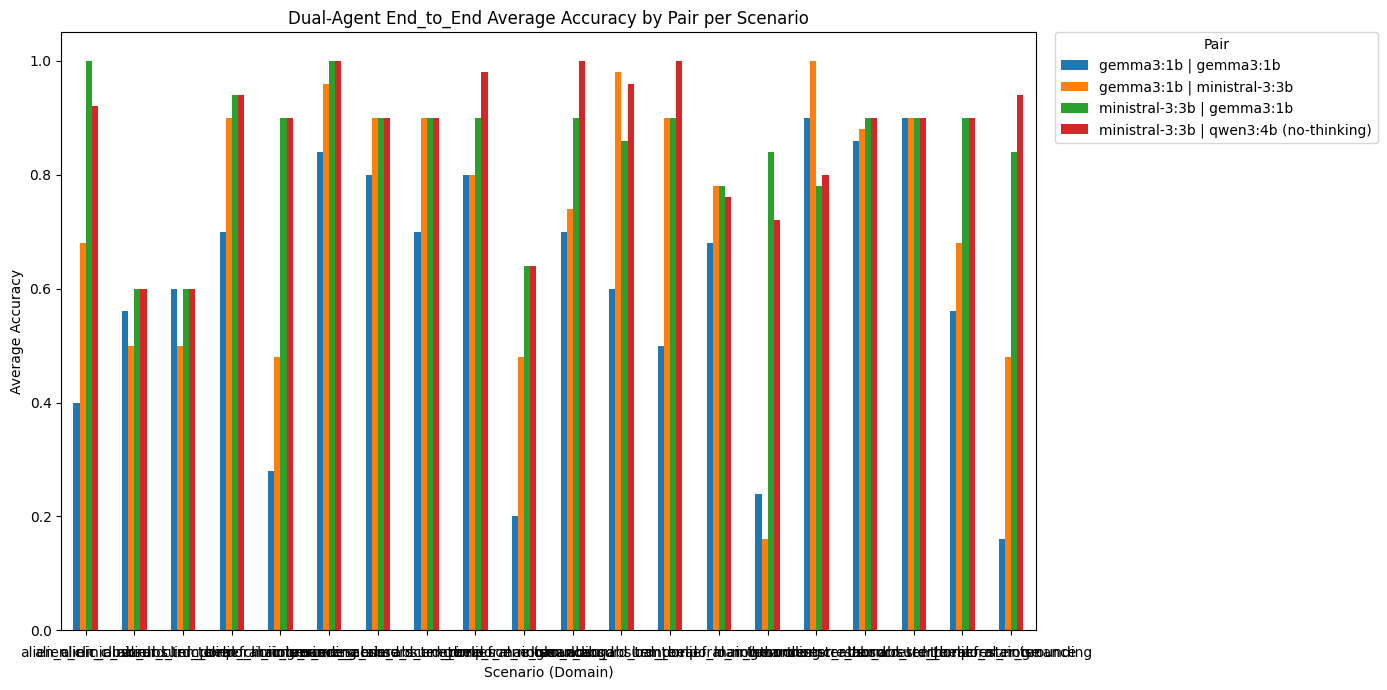

In [36]:
# End_to_End Average Accuracy by Reasoner/Matcher pair per scenario
if df_dual.empty:
    print("No data available for per-scenario accuracy plot.")
else:
    scenario_acc = df_dual[
        (df_dual["Metric_Family"] == "End_to_End")
        & (df_dual["Summary_Metric"] == "Average_Accuracy")
    ].copy()
    if scenario_acc.empty:
        print("No End_to_End Average_Accuracy rows found.")
    else:
        if "Pair" not in scenario_acc.columns:
            scenario_acc["Pair"] = scenario_acc["Reasoner_Model"].astype(str) + " | " + scenario_acc["Matcher_Model"].astype(str)

        # Group scenario ordering by type suffix
        type_order = [
            "absurd",
            "absurd_temporal",
            "absurd_temporal_noise",
            "grounding",
            "belief_maintenance",
        ]
        scenario_acc["Scenario_Type"] = scenario_acc["Domain"].astype(str).apply(
            lambda d: next((t for t in type_order if d.endswith(t)), "other")
        )
        scenario_acc["Scenario_Type"] = pd.Categorical(
            scenario_acc["Scenario_Type"],
            categories=type_order + ["other"],
            ordered=True,
        )
        scenario_acc = scenario_acc.sort_values(["Scenario_Type", "Domain"])

        pivot = scenario_acc.pivot_table(index="Domain", columns="Pair", values="Value", aggfunc="mean")
        print("Per-scenario End_to_End Average Accuracy (rows=Domain, cols=Pair):")
        display(pivot.round(4))
        ax = pivot.plot(kind="bar", figsize=(14, 7))
        ax.set_title("Dual-Agent End_to_End Average Accuracy by Pair per Scenario")
        ax.set_ylabel("Average Accuracy")
        ax.set_xlabel("Scenario (Domain)")
        ax.legend(title="Pair", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
        ax.tick_params(axis="x", labelrotation=0, pad=8)
        for label in ax.get_xticklabels():
            label.set_ha("center")
        plt.tight_layout()
        plt.show()
        plt.close(ax.figure)


Scenario-type aggregated Average Accuracy (rows=Type, cols=Pair):


Pair,gemma3:1b | gemma3:1b,gemma3:1b | ministral-3:3b,ministral-3:3b | gemma3:1b,ministral-3:3b | qwen3:4b (no-thinking)
Scenario_Type,,,,
absurd,0.710,0.845,0.920,0.930
absurd_temporal,0.705,0.815,0.815,0.840
absurd_temporal_noise,0.675,0.800,0.825,0.850
grounding,0.220,0.400,0.805,0.800
belief_maintenance,0.685,0.790,0.880,0.895


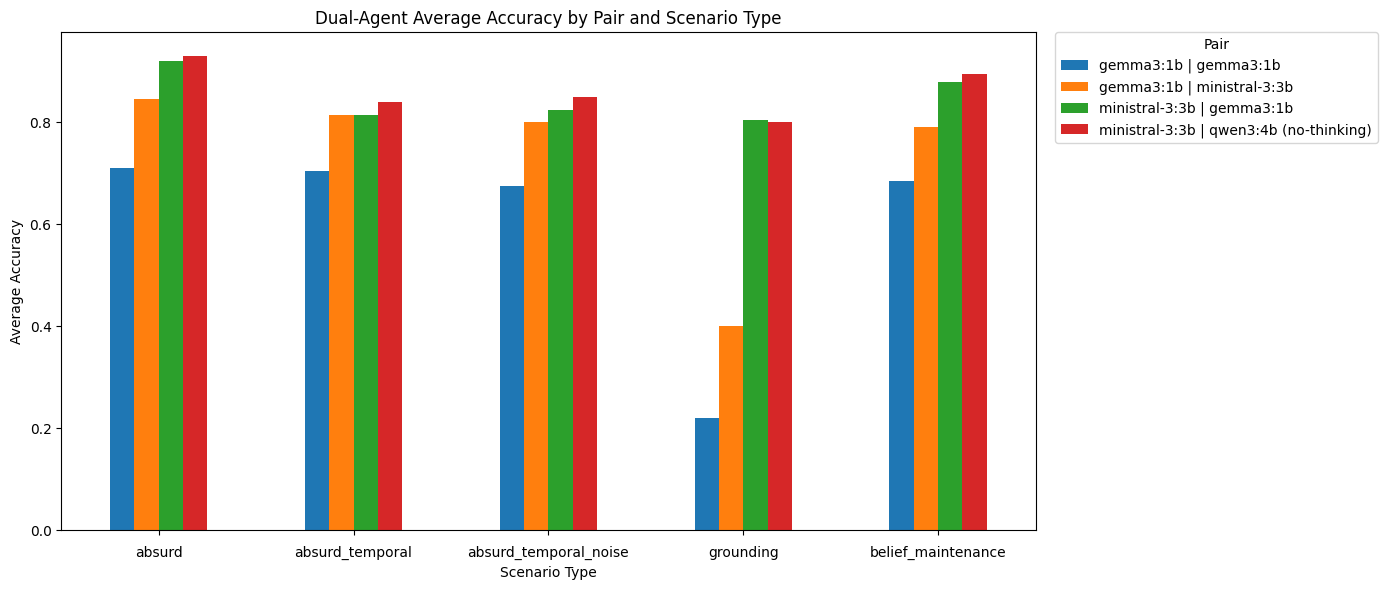

In [37]:
# End_to_End Average Accuracy by scenario type (aggregated) per pair
if df_dual.empty:
    print("No data available for scenario-type accuracy plot.")
else:
    type_acc = df_dual[
        (df_dual["Metric_Family"] == "End_to_End")
        & (df_dual["Summary_Metric"] == "Average_Accuracy")
    ].copy()
    if type_acc.empty:
        print("No End_to_End Average_Accuracy rows found.")
    else:
        if "Pair" not in type_acc.columns:
            type_acc["Pair"] = type_acc["Reasoner_Model"].astype(str) + " | " + type_acc["Matcher_Model"].astype(str)

        type_order = [
            "absurd",
            "absurd_temporal",
            "absurd_temporal_noise",
            "grounding",
            "belief_maintenance",
        ]
        type_acc["Scenario_Type"] = type_acc["Domain"].astype(str).apply(
            lambda d: next((t for t in type_order if d.endswith(t)), "other")
        )
        type_acc["Scenario_Type"] = pd.Categorical(
            type_acc["Scenario_Type"],
            categories=type_order + ["other"],
            ordered=True,
        )

        pivot = type_acc.pivot_table(index="Scenario_Type", columns="Pair", values="Value", aggfunc="mean")
        print("Scenario-type aggregated Average Accuracy (rows=Type, cols=Pair):")
        display(pivot.round(4))
        ax = pivot.plot(kind="bar", figsize=(14, 6))
        ax.set_title("Dual-Agent Average Accuracy by Pair and Scenario Type")
        ax.set_ylabel("Average Accuracy")
        ax.set_xlabel("Scenario Type")
        ax.legend(title="Pair", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
        ax.tick_params(axis="x", labelrotation=0, pad=8)
        for label in ax.get_xticklabels():
            label.set_ha("center")
        plt.tight_layout()
        plt.show()
        plt.close(ax.figure)


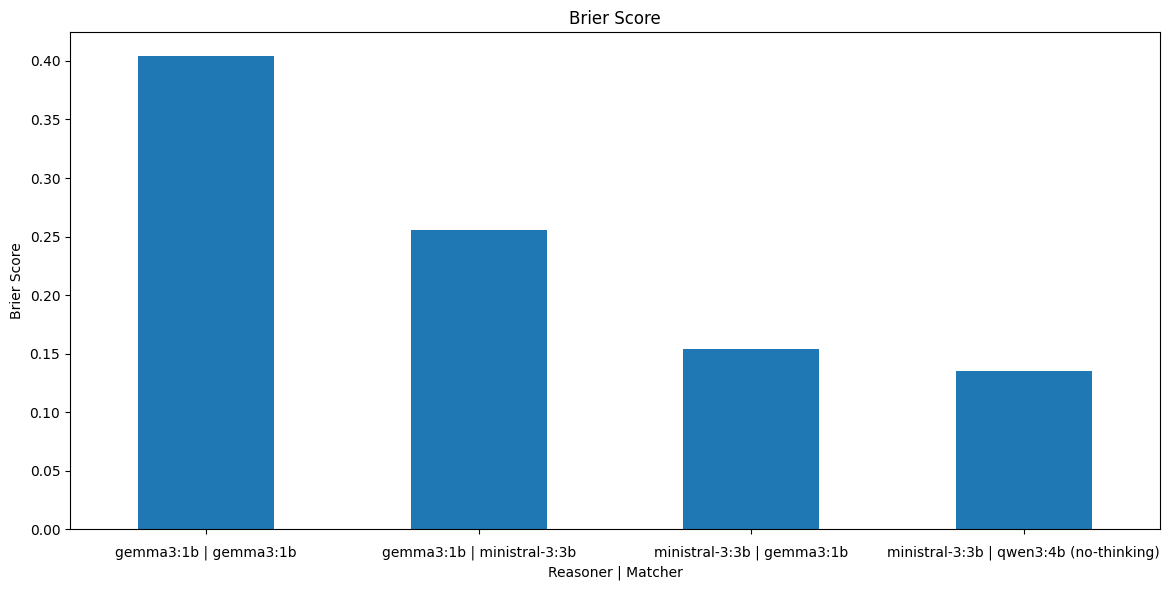

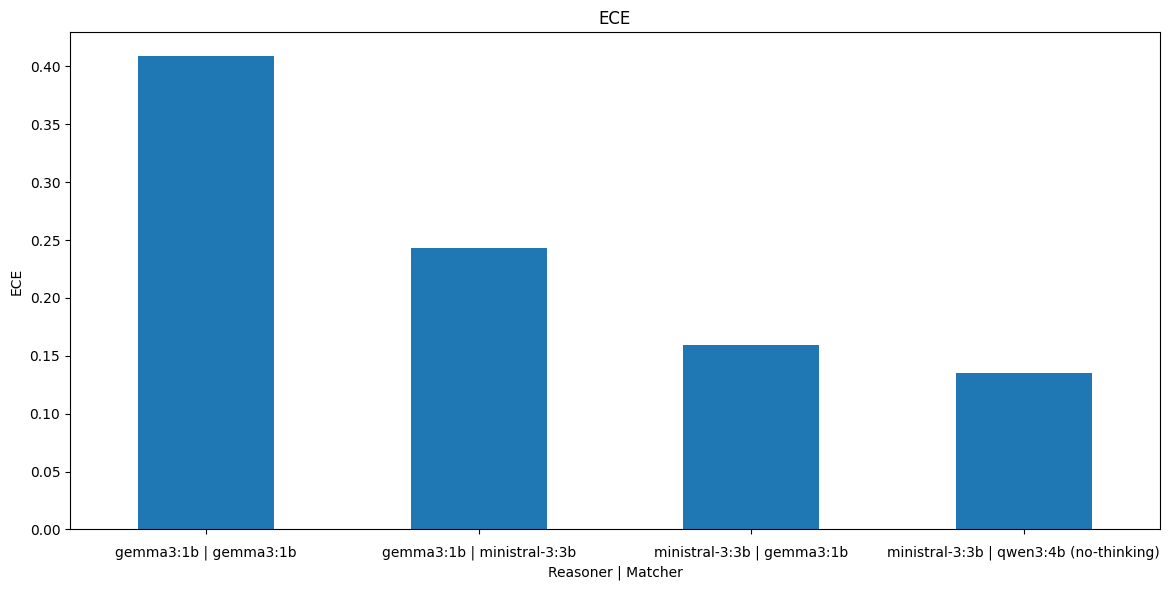

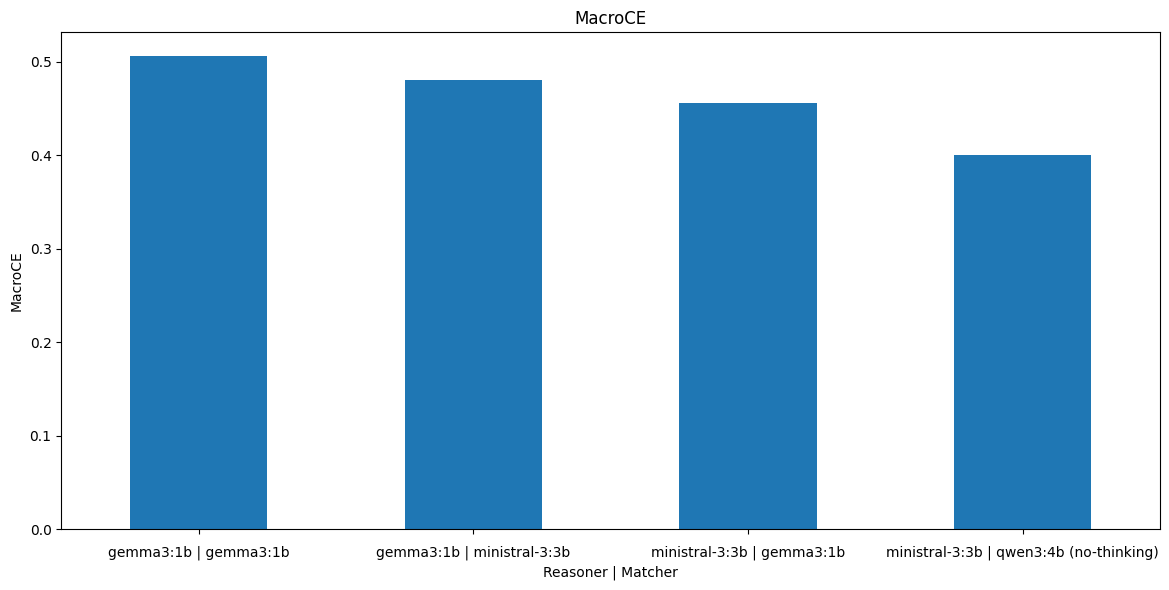

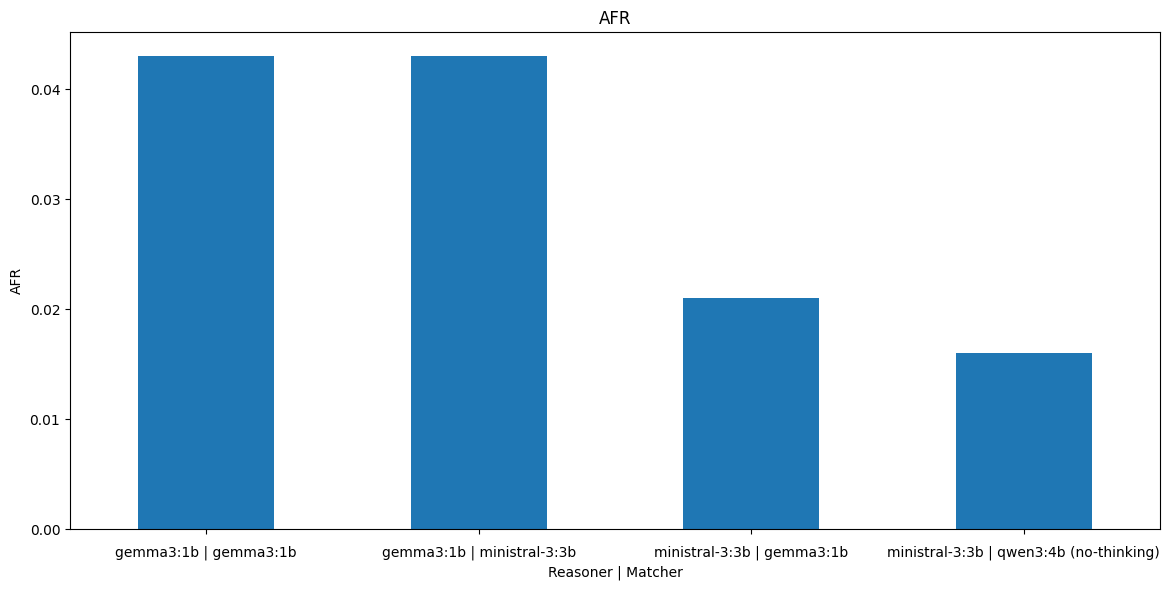

In [38]:
# Combined plots: Brier, ECE, MacroCE, AFR by reasoner/matcher pair
# (Separate charts with readable x-labels)
if df_dual.empty:
    print("No data available for combined metric plots.")
else:
    metrics_specs = [
        ("Matcher", ["Brier_Score", "Summary_Metric_Brier_Score"], "Brier Score"),
        ("Matcher", ["ECE", "Summary_Metric_ECE"], "ECE"),
        ("Matcher", ["MacroCE", "Summary_Metric_MacroCE"], "MacroCE"),
        ("Stability", ["AFR_Answer_Flip_Rate"], "AFR"),
    ]

    for family, metric_names, title in metrics_specs:
        sub = df_dual[
            (df_dual["Metric_Family"] == family)
            & (df_dual["Summary_Metric"].isin(metric_names))
        ].copy()
        if sub.empty:
            print(f"{title}: no data")
            continue
        if "Pair" not in sub.columns:
            sub["Pair"] = sub["Reasoner_Model"].astype(str) + " | " + sub["Matcher_Model"].astype(str)
        pivot = sub.pivot_table(index="Pair", values="Value", aggfunc="mean")
        ax = pivot.plot(kind="bar", figsize=(12, 6), legend=False)
        ax.set_title(title)
        ax.set_ylabel(title)
        ax.set_xlabel("Reasoner | Matcher")
        ax.tick_params(axis="x", labelrotation=0, pad=8)
        for label in ax.get_xticklabels():
            label.set_ha("center")
        plt.tight_layout()
        plt.show()
        plt.close(ax.figure)


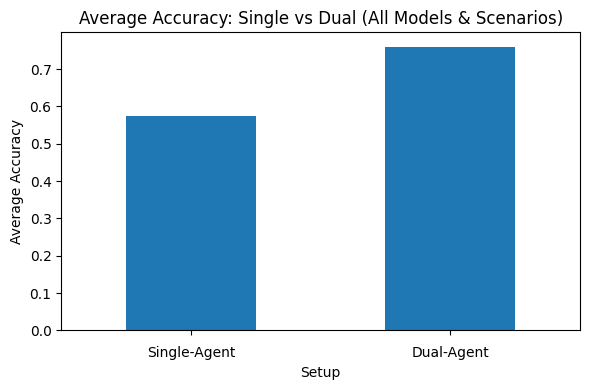

,Setup,Average_Accuracy
0,Single-Agent,0.575201
1,Dual-Agent,0.760250


In [39]:
# Single vs Dual: overall Average Accuracy (all models, all scenarios)
single_csv_path = "eval_results_normalized.csv"
try:
    df_single_raw = pd.read_csv(single_csv_path)
except FileNotFoundError:
    print(f"CSV not found: {single_csv_path}")
    df_single_raw = pd.DataFrame()

if df_single_raw.empty:
    print("Single-agent CSV is empty or missing.")
else:
    df_single = df_single_raw.copy()
    df_single["Summary_Metric"] = df_single["Summary_Metric"].astype(str)
    if "Value" in df_single.columns:
        df_single["Value"] = pd.to_numeric(df_single["Value"], errors="coerce")
        df_single = df_single[df_single["Value"].notna()].copy()

    single_acc = df_single[df_single["Summary_Metric"].str.lower() == "average_accuracy"]
    if single_acc.empty:
        print("No Average_Accuracy rows found in single-agent CSV.")
    else:
        single_avg_accuracy = single_acc["Value"].mean()

        # Dual-agent average accuracy (end-to-end)
        dual_acc = df_dual.copy()
        if "Summary_Metric" in dual_acc.columns:
            dual_acc["Summary_Metric"] = dual_acc["Summary_Metric"].astype(str)
        if "Metric_Family" in dual_acc.columns:
            dual_acc = dual_acc[
                (dual_acc["Metric_Family"] == "End_to_End")
                & (dual_acc["Summary_Metric"].str.lower() == "average_accuracy")
            ]
        else:
            dual_acc = dual_acc[dual_acc["Summary_Metric"].str.lower() == "average_accuracy"]

        if dual_acc.empty:
            print("No End_to_End Average_Accuracy rows found in dual-agent CSV.")
        else:
            dual_avg_accuracy = dual_acc["Value"].mean()

            compare_df = pd.DataFrame({
                "Setup": ["Single-Agent", "Dual-Agent"],
                "Average_Accuracy": [single_avg_accuracy, dual_avg_accuracy],
            })

            ax = compare_df.set_index("Setup").plot(
                kind="bar",
                legend=False,
                figsize=(6, 4),
)
            ax.set_title("Average Accuracy: Single vs Dual (All Models & Scenarios)")
            ax.set_ylabel("Average Accuracy")
            ax.set_xlabel("Setup")
            ax.tick_params(axis="x", labelrotation=0, pad=8)
            for label in ax.get_xticklabels():
                label.set_ha("center")
            plt.tight_layout()
            plt.show()
            plt.close(ax.figure)

            display(compare_df)